# Week 1 — Checkpoint 5: Visualization
### Dataset: `house_sale.csv` (bina.az — real estate sale listings)

**Goal:** Run three types of visualization on the `df_clean` prepared in the previous checkpoints: (1) distribution graphs, (2) a correlation heatmap, (3) categorical breakdown. After each chart I write a short "what am I seeing" observation.

## 1. Restoring the previous steps (Checkpoint 2 + 3 + 4)

In [6]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 70)
sns.set_style("whitegrid")

df = pd.read_csv('house_sale.csv')

df_clean = df.copy()
df_clean = df_clean.drop(columns=["Binanın növü", "hour_y"])
df_clean["featured_flag"] = df_clean["featured"].notnull()
df_clean["vip_flag"] = df_clean["vip"].notnull()
df_clean["mortgage_flag"] = df_clean["mortgage"].notnull()
df_clean["bill_of_sale_flag"] = df_clean["bill_of_sale"].notnull() | df_clean["Çıxarış"].notnull()
df_clean = df_clean.drop(columns=["featured", "vip", "mortgage", "İpoteka", "bill_of_sale", "Çıxarış", "repair"])
df_clean["Təmir"] = df_clean["Təmir"].fillna("Unknown")

def seller_type(row):
    if pd.notnull(row["shop_name"]):
        return "Agency"
    elif pd.notnull(row["owner_name"]):
        return "Individual"
    return "Unknown"

df_clean["seller_type"] = df_clean.apply(seller_type, axis=1)
for col in ["shop_name", "shop_title", "owner_name", "owner_title"]:
    df_clean[col] = df_clean[col].fillna("N/A")
df_clean["products_label"] = df_clean["products_label"].fillna("Regular listing")
df_clean["description"] = df_clean["description"].fillna("")

def parse_area(val):
    if pd.isnull(val):
        return np.nan
    val = val.strip()
    if "sot" in val:
        return float(val.replace("sot", "").strip().replace(",", ".")) * 100
    return float(val.replace("m²", "").strip().replace(" ", ""))

df_clean["Sahə_numeric"] = df_clean["Sahə"].apply(parse_area)
df_clean["unit_price_calculated"] = (df_clean["price"] / df_clean["Sahə_numeric"]).round(2)
df_clean = df_clean.drop(columns=["unit_price"])

applicable_categories = ["Köhnə tikili", "Yeni tikili", "Ofis", "Həyət evi/Bağ evi"]
mask = df_clean["Kateqoriya"].isin(applicable_categories)
medians = df_clean.loc[mask].groupby("Kateqoriya")["Otaq sayı"].median()
for cat, med in medians.items():
    idx = df_clean[(df_clean["Kateqoriya"] == cat) & (df_clean["Otaq sayı"].isnull())].index
    df_clean.loc[idx, "Otaq sayı"] = med

df_clean = df_clean[df_clean["price"] >= 1000].copy()

def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

def cap_grouped(df, col, group_col="Kateqoriya", k=1.5):
    capped = df[col].copy()
    flag = pd.Series(False, index=df.index)
    for cat, group in df.groupby(group_col):
        low, high = iqr_bounds(group[col].dropna(), k)
        idx = group.index
        below = df.loc[idx, col] < low
        above = df.loc[idx, col] > high
        flag.loc[idx[below | above]] = True
        capped.loc[idx[below]] = low
        capped.loc[idx[above]] = high
    return capped, flag

df_clean["price_capped"], df_clean["is_outlier_price"] = cap_grouped(df_clean, "price")
df_clean["Sahə_numeric_capped"], df_clean["is_outlier_area"] = cap_grouped(df_clean, "Sahə_numeric")
df_clean["unit_price_capped"], df_clean["is_outlier_unit_price"] = cap_grouped(df_clean, "unit_price_calculated")

low_v, high_v = iqr_bounds(df_clean["views"])
df_clean["views_capped"] = df_clean["views"].clip(low_v, high_v)

floor_split = df_clean["Mərtəbə"].str.split("/", expand=True)
df_clean["floor_current"] = pd.to_numeric(floor_split[0].str.strip(), errors="coerce")
df_clean["floor_total"] = pd.to_numeric(floor_split[1].str.strip(), errors="coerce")
df_clean["floor_ratio"] = (df_clean["floor_current"] / df_clean["floor_total"]).round(2)
df_clean["is_top_floor"] = df_clean["floor_current"] == df_clean["floor_total"]
df_clean["is_ground_floor"] = df_clean["floor_current"] == 1

def loc_type(loc):
    if pd.isnull(loc):
        return "Unknown"
    match = re.search(r"\s(r|m|q)\.$", loc.strip())
    mapping = {"r": "District center", "m": "Micro-district", "q": "Settlement"}
    return mapping.get(match.group(1), "Other") if match else "Other"

df_clean["location_type"] = df_clean["location"].apply(loc_type)

df_clean["price_per_room"] = np.where(
    df_clean["Otaq sayı"] > 0, (df_clean["price_capped"] / df_clean["Otaq sayı"]).round(0), np.nan
)
category_median = df_clean.groupby("Kateqoriya")["price_capped"].transform("median")
df_clean["price_index_vs_category"] = (df_clean["price_capped"] / category_median).round(2)

print("df_clean is ready:", df_clean.shape)


df_clean is ready: (100765, 63)


## 2. Distribution graphs

Looking at the distribution of the key numeric columns: `price_capped`, `Sahə_numeric_capped` (area), `unit_price_capped` (price per m²). Using the capped versions so the extreme values I limited in Checkpoint 3 don't "compress" the chart and make it unreadable.

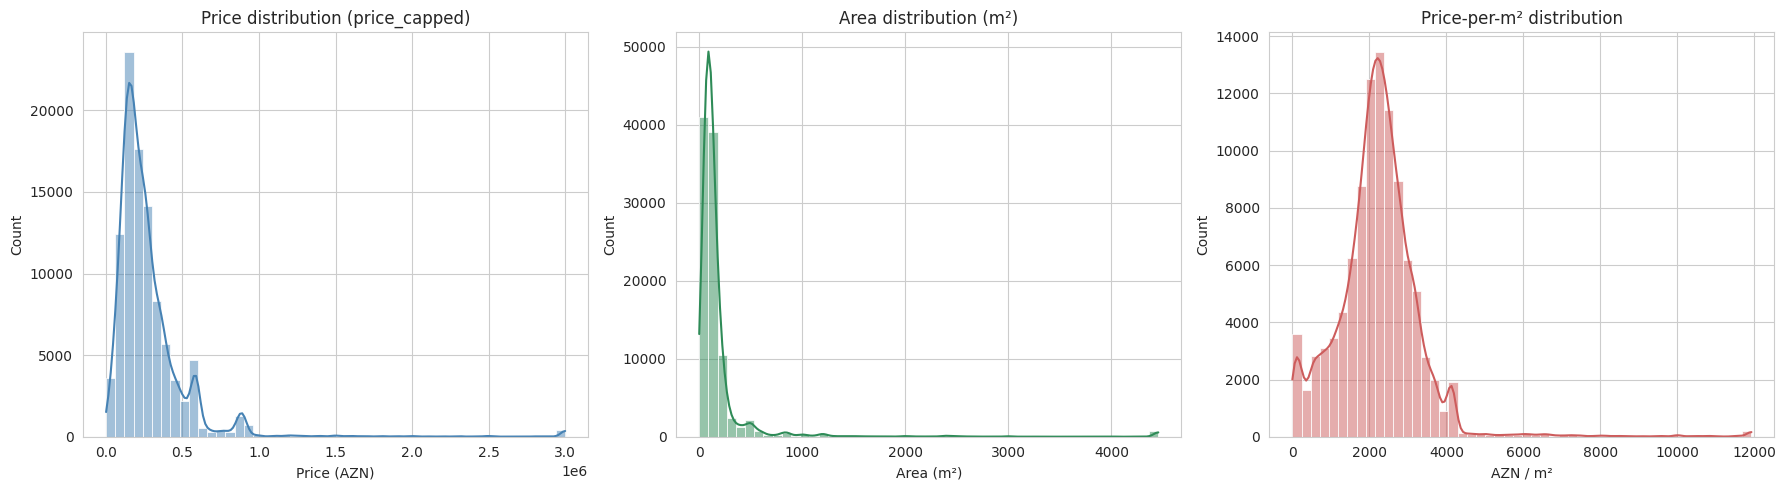

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df_clean["price_capped"], bins=50, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Price distribution (price_capped)")
axes[0].set_xlabel("Price (AZN)")

sns.histplot(df_clean["Sahə_numeric_capped"], bins=50, kde=True, ax=axes[1], color="seagreen")
axes[1].set_title("Area distribution (m²)")
axes[1].set_xlabel("Area (m²)")

sns.histplot(df_clean["unit_price_capped"], bins=50, kde=True, ax=axes[2], color="indianred")
axes[2].set_title("Price-per-m² distribution")
axes[2].set_xlabel("AZN / m²")

plt.tight_layout()
plt.show()


**Observation:** Even after capping, all three distributions remain right-skewed — normal for a real-estate market (most listings cluster in the mid-segment, with a small number of luxury/large properties forming the "tail"). The bulk of `price_capped` falls in the 100,000–400,000 AZN range, while `Sahə_numeric_capped` peaks in the 50–150 m² range — consistent with a standard apartment size in the Baku market.

## 3. Correlation heatmap

Visualizing the correlation matrix to see the linear relationships among the numeric columns. I include the new columns created in Checkpoint 4 (`price_per_room`, `price_index_vs_category`, `floor_ratio`) to check whether they have a genuine relationship with price.

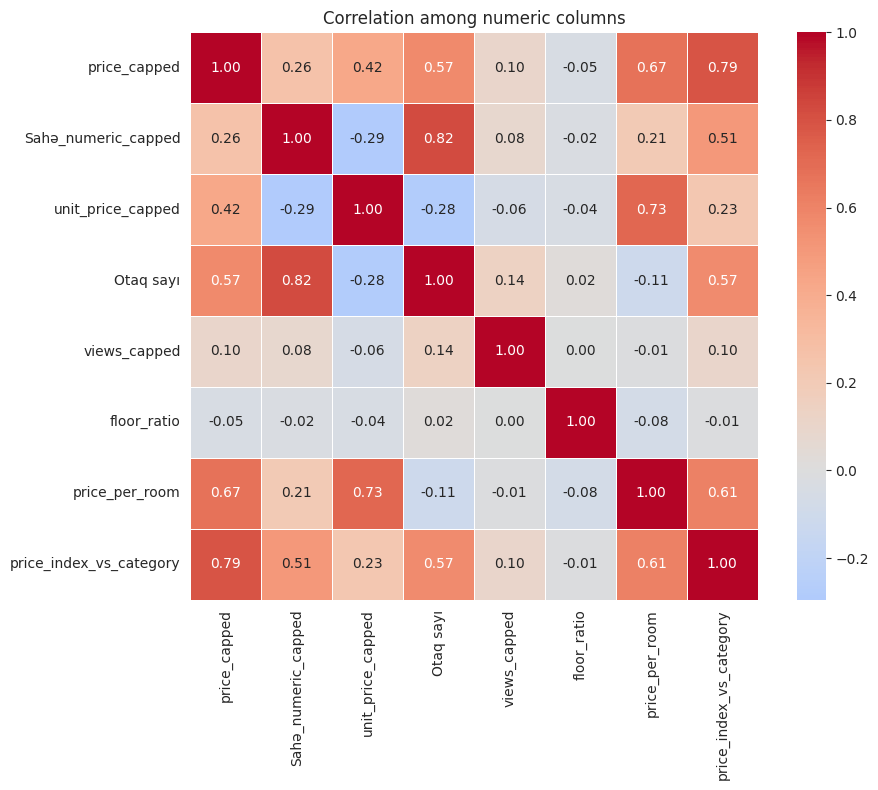

In [8]:
numeric_cols = [
    "price_capped", "Sahə_numeric_capped", "unit_price_capped",
    "Otaq sayı", "views_capped", "floor_ratio",
    "price_per_room", "price_index_vs_category"
]

corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5)
plt.title("Correlation among numeric columns")
plt.tight_layout()
plt.show()


**Observation:**
- The strongest positive correlation with `price_capped` is with `price_index_vs_category` (0.79) and `price_per_room` (0.67) — expected, since both are directly derived from `price_capped`.
- `Otaq sayı` (room count) has a moderate positive correlation with `price_capped` (0.57) — more rooms generally means a higher price, which makes sense.
- The correlation between `Sahə_numeric_capped` (area) and `price_capped` is weaker than expected (0.26) — likely because different categories (land vs. apartment) have very different area-to-price ratios (land is large but relatively cheap per m²).
- `floor_ratio` shows almost no relationship (-0.05) — floor position alone doesn't strongly affect price; it would need to be examined together with other factors (district, area).
- `views_capped`'s relationship with price is very weak (0.10) — view count reflects a listing's popularity, not its price.

## 4. Categorical breakdown

Showing how `Kateqoriya` (property category) breaks down both by listing count and by price.

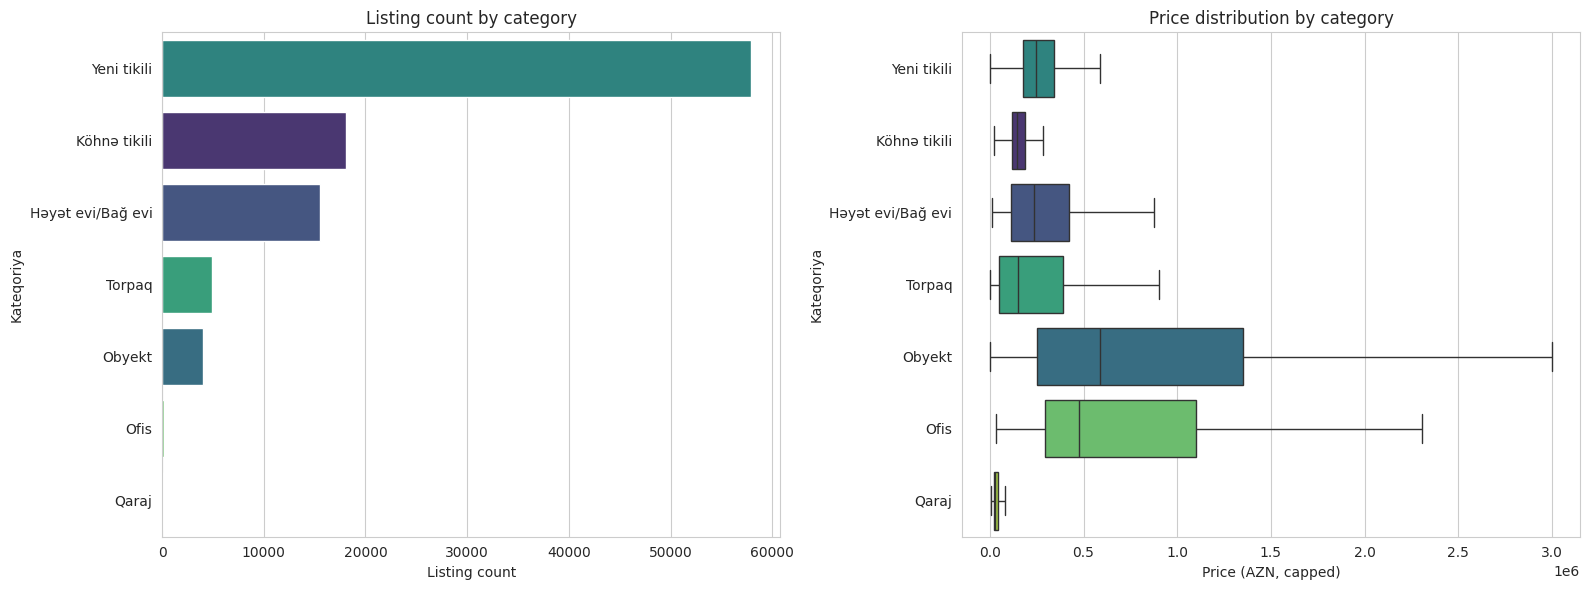

In [9]:
order = df_clean["Kateqoriya"].value_counts().index

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=df_clean, y="Kateqoriya", order=order, ax=axes[0], hue="Kateqoriya", legend=False, palette="viridis")
axes[0].set_title("Listing count by category")
axes[0].set_xlabel("Listing count")

sns.boxplot(data=df_clean, x="price_capped", y="Kateqoriya", order=order, ax=axes[1], hue="Kateqoriya", legend=False, palette="viridis")
axes[1].set_title("Price distribution by category")
axes[1].set_xlabel("Price (AZN, capped)")

plt.tight_layout()
plt.show()


**Observation:** The vast majority of listings fall under `Yeni tikili` (new-construction apartments, 57%) and `Köhnə tikili` (older apartments, 18%) — the apartment segment dominates the market. By price, `Obyekt` (commercial) has the widest spread (largest IQR box) and the highest median price, while `Qaraj` (garage), as expected, sits at the lowest price segment.

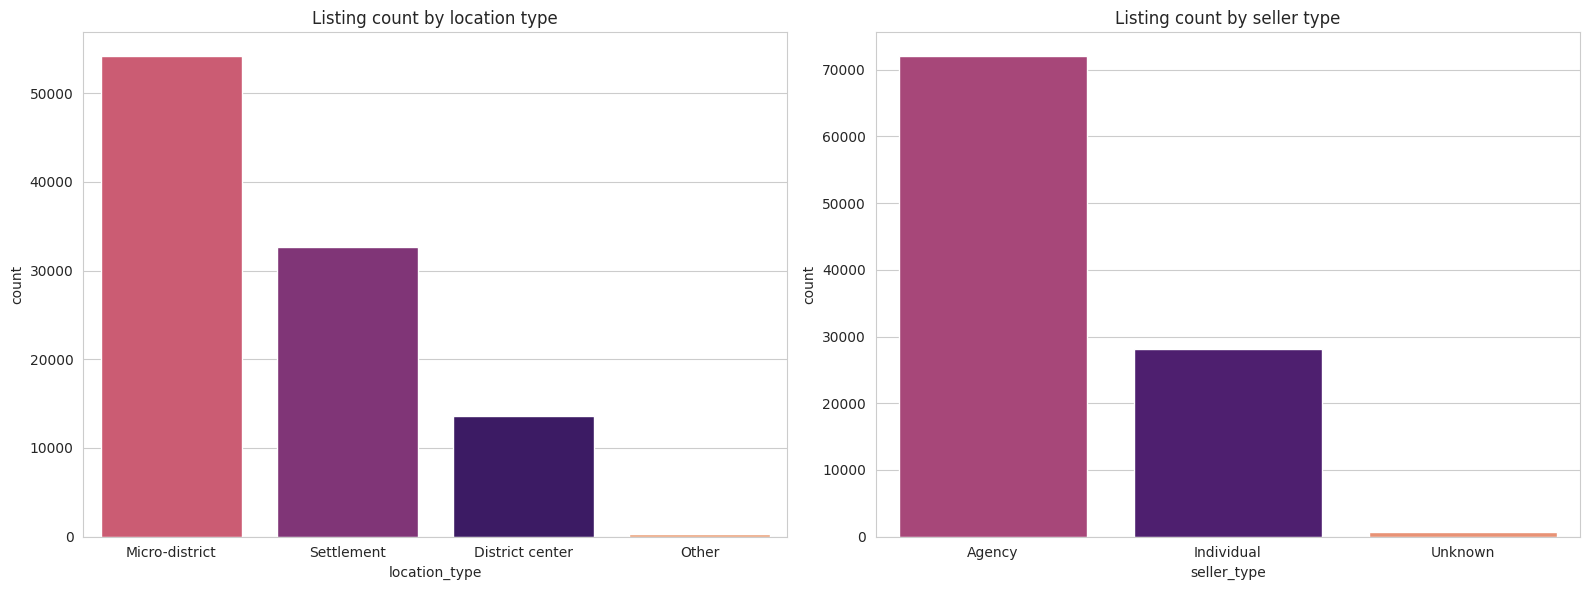

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=df_clean, x="location_type", order=df_clean["location_type"].value_counts().index, ax=axes[0], hue="location_type", legend=False, palette="magma")
axes[0].set_title("Listing count by location type")

sns.countplot(data=df_clean, x="seller_type", order=df_clean["seller_type"].value_counts().index, ax=axes[1], hue="seller_type", legend=False, palette="magma")
axes[1].set_title("Listing count by seller type")

plt.tight_layout()
plt.show()


**Observation:** Most listings are in `Micro-district`-type locations (54%), while `Settlement` holds a surprisingly large share (32%) — indicating an active construction/sales market in Baku's surrounding settlements (Mərdəkan, Şüvəlan, etc.). By seller type, `Individual` sellers account for the majority of listings, with `Agency` holding a relatively smaller share.

## Checkpoint 5 — Summary

- **Distribution graphs:** `price_capped`, `Sahə_numeric_capped`, `unit_price_capped` remain right-skewed even after capping — the market's bulk is concentrated in the mid-segment.
- **Correlation heatmap:** `Otaq sayı` has a moderate-strong positive relationship with price (0.57); the Checkpoint-4 features `price_per_room`/`price_index_vs_category` are, as expected, strongly correlated with `price_capped` (since they're derived from it); `floor_ratio` alone showed no meaningful effect on price.
- **Categorical breakdown:** The market is dominated by the `Yeni tikili`/`Köhnə tikili` apartment segment; `Obyekt` (commercial) is the highest-priced category and `Qaraj` (garage) the lowest; a meaningful share of listings (~32%) come from Baku's settlement areas and are mostly posted by individual sellers.
